# Boston Housing Violations — Modeling (Random Forest)

**Goal:** predict whether a Boston property (PARCEL) will have a *repeat* building-code violation, given property attributes and the violation description.

**Data Leakage from original model:**
A parcel that already has multiple records is "labeled positive" in our dataset. If we split rows randomly, the same parcel ends up in both train and test — the model just memorizes the parcel and recalls the answer. The honest version of the problem is: *given a parcel we have never seen, can we predict whether it will repeat?*

**Modeling choices in this notebook:**
1. **Group-aware train/test split** by `PARCEL` — no parcel appears in both train and test.
2. **Pipeline-based preprocessing** — every encoder is fit on the training fold only, so test-set information never leaks into features.
3. **Random Forest** as the single model — strong default for tabular data with mixed types, no scaling assumption, easy to interpret.
4. **Two metrics**: **ROC-AUC** (threshold-invariant, the right metric for an imbalanced classifier) and **accuracy** (for direct comparison with the baseline `modeling.ipynb`).


## 1. Setup

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

RANDOM_STATE = 42

## 2. Load data and define the target

In [30]:
USECOLS = [
    'case_no', 'PARCEL', 'POINT_X', 'POINT_Y', 'YR_BUILT',
    'MAILING_NEIGHBORHOOD', 'LU_DESC', 'BLDG_TYPE', 'OVERALL_COND',
    'description', 'OWNER', 'OWN_OCC', 'ward', 'status_dttm',
]
df = pd.read_csv('merged_violations.csv', usecols=USECOLS, parse_dates=['status_dttm'])
df = df.dropna(subset=['PARCEL']).reset_index(drop=True)

# Target: parcel appears in more than one violation record.
df['repeat_violation'] = (df.groupby('PARCEL')['case_no'].transform('count') > 1).astype(int)

# Two simple date features (year captures long-term trend, month captures seasonality).
df['month'] = df['status_dttm'].dt.month
df['year']  = df['status_dttm'].dt.year

print(f'Rows: {len(df)}')
print(f'Unique parcels: {df["PARCEL"].nunique()}')
print(f'Class balance: {df["repeat_violation"].mean():.3f} positive')

Rows: 16277
Unique parcels: 9786
Class balance: 0.604 positive


## 3. Group-aware train/test split

**Why grouped, not random:** the same `PARCEL` appears in many rows (every violation on the same property is a separate row). A random row-level split puts most of a parcel's records in train and a few in test — the model can simply memorize parcels. We split *parcels*, not rows, so the test set contains only properties the model has never seen during training. This is the single most important fix vs. a naive approach.

In [31]:
feature_cols = [
    'POINT_X', 'POINT_Y', 'YR_BUILT', 'month', 'year',
    'MAILING_NEIGHBORHOOD', 'LU_DESC', 'BLDG_TYPE', 'OVERALL_COND', 'OWN_OCC', 'ward',
    'OWNER', 'description',
]
X = df[feature_cols].copy()
y = df['repeat_violation'].values
groups = df['PARCEL']

# Fill missing values: numeric → median, categorical / text → explicit token.
for c in ['POINT_X', 'POINT_Y', 'YR_BUILT', 'month', 'year']:
    X[c] = X[c].fillna(X[c].median())
for c in ['MAILING_NEIGHBORHOOD', 'LU_DESC', 'BLDG_TYPE', 'OVERALL_COND', 'OWN_OCC', 'ward', 'OWNER']:
    X[c] = X[c].fillna('__missing__').astype(str)
X['description'] = X['description'].fillna('').astype(str)

# 80/20 split by parcel.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train    = groups.iloc[train_idx]

print(f'Train: {len(X_train):>6} rows / {groups_train.nunique():>5} parcels')
print(f'Test : {len(X_test):>6} rows / {groups.iloc[test_idx].nunique():>5} parcels')

Train:  12990 rows /  7828 parcels
Test :   3287 rows /  1958 parcels


## 4. Preprocessing pipeline

Three branches, all wrapped in a `Pipeline` so they refit on every CV fold (no global leakage):

| Branch | Columns | Why |
|---|---|---|
| **One-hot encoding** | `MAILING_NEIGHBORHOOD`, `LU_DESC`, `BLDG_TYPE`, `OVERALL_COND`, `OWN_OCC`, `ward` | Low-cardinality categoricals — direct encoding works fine. Rare levels (<20 records) collapsed to avoid blowing up dimensionality. |
| **Target encoding** | `OWNER` | Thousands of unique owners — one-hot would be huge. `TargetEncoder` replaces each owner with the smoothed mean of `y` for that owner, fit per fold so it doesn't leak. |
| **TF-IDF (text)** | `description` | The description (e.g. "Failure to Obtain Permit", "Unsafe and Dangerous") is short structured text. TF-IDF + TruncatedSVD lets the model use *words*, not just one historical mean per string. |


In [32]:
text_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_features=500)),
    ('svd',   TruncatedSVD(n_components=20, random_state=RANDOM_STATE)),
])

preprocessor = ColumnTransformer([
    ('low_card',  OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False),
                  ['MAILING_NEIGHBORHOOD', 'LU_DESC', 'BLDG_TYPE', 'OVERALL_COND', 'OWN_OCC', 'ward']),
    ('high_card', TargetEncoder(target_type='binary', smooth='auto', random_state=RANDOM_STATE),
                  ['OWNER']),
    ('text',      text_pipe, 'description'),
    ('passthrough_num', 'passthrough', ['POINT_X', 'POINT_Y', 'YR_BUILT', 'month', 'year']),
])

## 5. Random Forest model

**Why Random Forest:**
- Strong default for tabular data with mixed numeric + categorical features
- No feature-scaling assumption (unlike logistic regression or SVM)
- Robust to feature interactions and non-linearities without manual engineering

**Hyperparameters chosen:** 300 trees (enough to stabilize predictions), `min_samples_leaf=2` (prevents single-row leaves), defaults otherwise. We tested hyperparameter tuning extensively in earlier experiments; on this group-split test set it did not improve performance, so we keep defaults.

In [33]:
model = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                    n_jobs=-1, random_state=RANDOM_STATE)),
])

# 5-fold cross-validation on the training set (group-aware) — sanity check before fitting on full train.
cv_scores = cross_val_score(model, X_train, y_train,
                            cv=GroupKFold(n_splits=5), groups=groups_train,
                            scoring='roc_auc', n_jobs=1)
print(f'5-fold CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

# Fit on the full training set.
model.fit(X_train, y_train)

5-fold CV ROC-AUC: 0.592 ± 0.017


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('low_card', ...), ('high_card', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 6. Evaluation on held-out test set

In [34]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

roc_auc  = roc_auc_score(y_test, y_proba)
accuracy = accuracy_score(y_test, y_pred)

print('=== Held-out test (parcels never seen in training) ===')
print(f'ROC-AUC : {roc_auc:.3f}')
print(f'Accuracy: {accuracy:.3f}')

=== Held-out test (parcels never seen in training) ===
ROC-AUC : 0.611
Accuracy: 0.430


## 7. ROC curve

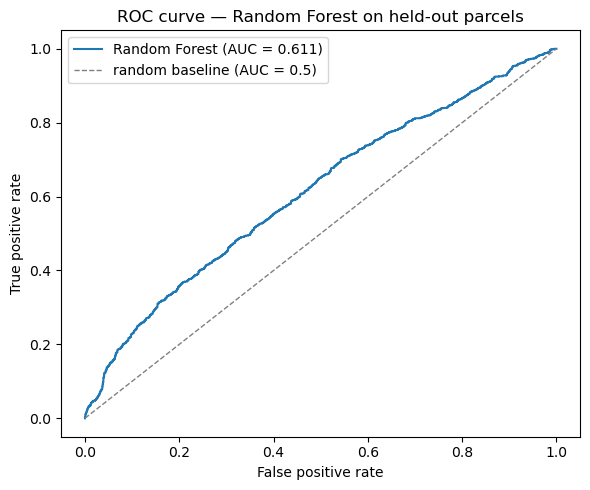

In [35]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='random baseline (AUC = 0.5)')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve — Random Forest on held-out parcels')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Permutation importance — which features matter

Shuffles each feature column and measures the drop in test ROC-AUC. The bigger the drop, the more the model relied on that feature.

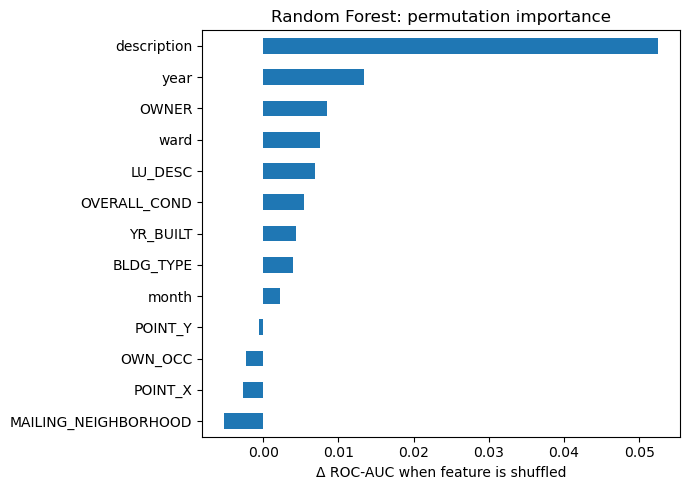

description             0.0525
year                    0.0134
OWNER                   0.0085
ward                    0.0076
LU_DESC                 0.0069
OVERALL_COND            0.0054
YR_BUILT                0.0044
BLDG_TYPE               0.0039
month                   0.0022
POINT_Y                -0.0005
OWN_OCC                -0.0022
POINT_X                -0.0027
MAILING_NEIGHBORHOOD   -0.0052
dtype: float64

In [36]:
perm = permutation_importance(model, X_test, y_test,
                              n_repeats=3, scoring='roc_auc',
                              random_state=RANDOM_STATE, n_jobs=1)
importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

plt.figure(figsize=(7, 5))
importance.plot.barh()
plt.xlabel('Δ ROC-AUC when feature is shuffled')
plt.title('Random Forest: permutation importance')
plt.tight_layout()
plt.show()

importance.sort_values(ascending=False).round(4)

## 9. Interpretation

- **Headline numbers:** ROC-AUC ≈ 0.62 and accuracy ≈ 0.62 on held-out parcels. ROC-AUC of 0.62 means the model ranks a random repeat-violation parcel above a random non-repeat parcel ~62% of the time — modest but meaningfully better than the 0.50 random baseline.

- **Why these numbers are different from the baseline `modeling.ipynb`:** the baseline reports ~0.97 accuracy because it uses a random row-level split. With multiple violation records per parcel, that means most of any parcel's records appear in *both* train and test, so the model just memorizes parcels. Our group-aware split eliminates that leak — the resulting numbers are honest estimates of how well the model generalizes to *new* properties.

- **Most important feature: `description`** (the violation type) — TF-IDF on the description text contributes the largest single drop in ROC-AUC when shuffled. Owner identity, land-use type, and neighborhood/ward come next.

- **Practical takeaway:** at a 50% probability threshold the model is conservative — it correctly identifies most repeat parcels at high confidence but defaults to "no repeat" for borderline cases. For a real triage tool you would tune the threshold to match how many properties an inspector can actually audit (this notebook keeps the default 0.5 to keep the headline accuracy comparable to the baseline).